In [1]:
%load_ext autoreload
%autoreload 2

# Network Scoring

This notebook will show how to score individual learning events accross trials for a given experiment/optimizer run. These score metrics will then be aggregate to compare accross optimizers/experiments.

In [2]:
import sys
from pathlib import Path

# Ensure the project root is on sys.path so we can import from visualize_webapp.
_PROJECT_ROOT = Path(".").resolve()
if str(_PROJECT_ROOT) not in sys.path:
	sys.path.insert(0, str(_PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
from IPython.display import display

pio.renderers.default = "notebook"
# White backgrounds (app builders use transparent _style(); dark notebook themes need this)
pio.templates.default = "plotly_white"
import visualize_webapp.app as _vwa

# Save the real _style only once — re-running this cell must not alias the wrapper to itself.
if not hasattr(_vwa, "_style_original"):
	_vwa._style_original = _vwa._style


def _style_white_bg(fig, **kw):
	_vwa._style_original(fig, **kw)
	fig.update_layout(paper_bgcolor="white", plot_bgcolor="white")
	return fig


_vwa._style = _style_white_bg

from visualize_webapp.post_processing import (
	_pp_neuron_digit,
	_pp_dead,
	_pp_train_act,
)

from typing import cast

from visualize_webapp.app import (
	scan_results,
	_metrics,
	_nts,
	_compact_neuron_label,
	_build_layer_inactive_count,
	_build_layer_digit_count_plot,
	_build_layer_digit_count_non_head_combined,
	_build_recovery_cumsum_plot,
	_build_dead_layer_traces,
	_build_dead_neuron_pre_nl_grid,
	_build_dead_neuron_inactivity_bar,
	_weights_sample_matrix,
)
from visualize_webapp.notebook.network_analysis_mpl import (
	mpl_dead_layer_traces,
	mpl_layer_digit_count_non_head_combined,
	mpl_layer_digit_count_plot,
	mpl_layer_inactive_count,
	mpl_neuron_assigned_digit_count_over_time,
	mpl_neuron_eval_activation_angle_over_time,
	mpl_neuron_eval_activation_mean_over_time,
	mpl_recovery_cumsum,
)
from visualize_webapp.post_processing import (
	per_neuron_recovery_counts,
	split_ever_dead_by_final_checkpoint,
)

from matplotlib.gridspec import GridSpec
from visualize_webapp.app import (
	_NETWORK_N_DIGITS,
	_NETWORK_SAMPLES_PER_DIGIT,
	_NETWORK_EVAL_K_LINE_COLORS,
	C,
)


## Configuration

Set the four identifiers below to select which run to analyse.
Run the **Discovery** cell first if you are unsure of the exact string values.

In [3]:
tree = scan_results()
for eid, models in sorted(tree.items()):
	for mid, runs in sorted(models.items()):
		for rid, oids in sorted(runs.items()):
			for oid in oids:
				print(f"  experiment={eid!r}  model={mid!r}  run={rid!r}  optimizer={oid!r}")

  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='sgd_lr0.01'
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='adagrad_lr0.01'
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='adam_lr0.01'
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='pure_shampoo_lr0.01'
  experiment='digit_ordered_0_1_75_25_tr100'  model='dnn_5x64'  run='0d4f4a'  optimizer='grafted_shampoo_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  run='6c35d5'  optimizer='sgd_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  run='6c35d5'  optimizer='adagrad_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  run='6c35d5'  optimizer='adam_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  run='6c35d5'  optimizer='pure_shampoo_lr0.01'
  experiment='pretrainK1000_tr100_then_0'  model='dnn_5x64'  ru

In [4]:
# __ CONFIG ____________________________________________________________
MODEL_ID	  = "dnn_5x64"
EXPERIMENT_ID = "pretrain_0_mislabel1_1_K1000_tr100" # trick to change the results dir from results/ to results_old/
RUN_ID		= "4a7338"
OPTIMIZER_ID  = "grafted_shampoo_lr0.01"

USE_BOXPLOT = False
# When True, sections above "Dead neuron detail" use matplotlib instead of Plotly.
USE_MATPLOTLIB = True


SHOW_PLOTS = True
# ____________________________________________________________________________

N_SAMPLES_PER_EVALUATION_DIGIT = 5
N_SAMPLES_PER_TRIAL = 100

# ____________________________________________________________________________

## Data loading

In [5]:
metrics = _metrics(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False)

def nan_to_len(checkpoint_idx):
	if np.isnan(checkpoint_idx):
		return len(metrics["checkpoint_iterations"])
	else:
		assert isinstance(checkpoint_idx, (int,float))
		return int(checkpoint_idx)

def get_iteration(checkpoint_idx):
	cp_idx = nan_to_len(checkpoint_idx)
	return metrics["checkpoint_iterations"][cp_idx+1] if cp_idx < len(metrics["checkpoint_iterations"])-1 else (metrics["checkpoint_iterations"][-1]+1)
df_nd   = cast(pd.DataFrame,_pp_neuron_digit(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False))
df_nd["n_active"] = df_nd["status"].apply(lambda s: 0 if s == "inactive" else (N_SAMPLES_PER_EVALUATION_DIGIT if s == "assigned" else int(s.split("_")[-1])) )
df_nd["iteration"] = df_nd["checkpoint_idx"].map(get_iteration)

df_dead = cast(pd.DataFrame,_pp_dead(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False))
df_dead["iteration"] = df_dead["checkpoint_idx"].map(get_iteration)

pp_ta   = _pp_train_act(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False)
nts	 = _nts(EXPERIMENT_ID, MODEL_ID, OPTIMIZER_ID, rid=RUN_ID, w_cache=False)


if df_nd is None or df_nd.empty:
	print("WARNING: post_processing_neuron_digit.csv not found for this run.")
	print("Re-run training to generate post-processing data.")
else:
	layer_order = list(dict.fromkeys(df_nd["layer_name"].tolist()))
	print(f"Layers: {layer_order}")

if df_dead is None or df_dead.empty:
	ever_dead_nids = []
	dead_at_end_nids = set()
	recovered_dead_nids = set()
	print("No dead-neuron data found.")
else:
	ever_dead_nids = sorted(df_dead[df_dead["is_dead"]]["neuron_id"].unique().tolist())
	dead_at_end_nids, recovered_dead_nids = split_ever_dead_by_final_checkpoint(df_dead)
	print(f"Dead neurons ({len(ever_dead_nids)}): {ever_dead_nids}")
	print(
		f"  Still dead at last checkpoint (perpetually dead at end): {len(dead_at_end_nids)}"
	)
	print(f"  Recovered dead (alive at last checkpoint): {len(recovered_dead_nids)}")

Layers: ['hidden.0', 'hidden.2', 'hidden.4', 'hidden.6', 'hidden.8', 'head']
Dead neurons (56): ['dnn|hidden.0|neuron|1', 'dnn|hidden.0|neuron|17', 'dnn|hidden.0|neuron|26', 'dnn|hidden.0|neuron|29', 'dnn|hidden.0|neuron|31', 'dnn|hidden.0|neuron|33', 'dnn|hidden.0|neuron|35', 'dnn|hidden.0|neuron|38', 'dnn|hidden.0|neuron|39', 'dnn|hidden.0|neuron|5', 'dnn|hidden.0|neuron|50', 'dnn|hidden.0|neuron|54', 'dnn|hidden.2|neuron|10', 'dnn|hidden.2|neuron|19', 'dnn|hidden.2|neuron|35', 'dnn|hidden.2|neuron|39', 'dnn|hidden.2|neuron|42', 'dnn|hidden.2|neuron|52', 'dnn|hidden.2|neuron|57', 'dnn|hidden.4|neuron|10', 'dnn|hidden.4|neuron|16', 'dnn|hidden.4|neuron|2', 'dnn|hidden.4|neuron|20', 'dnn|hidden.4|neuron|21', 'dnn|hidden.4|neuron|33', 'dnn|hidden.4|neuron|43', 'dnn|hidden.4|neuron|46', 'dnn|hidden.4|neuron|50', 'dnn|hidden.4|neuron|52', 'dnn|hidden.4|neuron|61', 'dnn|hidden.4|neuron|8', 'dnn|hidden.6|neuron|16', 'dnn|hidden.6|neuron|18', 'dnn|hidden.6|neuron|23', 'dnn|hidden.6|neuron|26

In [6]:
print("df_nd")
display(df_nd.head(5))
print("df_dead")
display(df_dead.head(5))

df_nd


,neuron_id,layer_name,checkpoint_idx,checkpoint_tag,digit,status,n_active,iteration
0,dnn|hidden.0|neuron|0,hidden.0,0,init,0,inactive,0,0
1,dnn|hidden.0|neuron|0,hidden.0,0,init,1,assigned,5,0
2,dnn|hidden.0|neuron|0,hidden.0,0,init,2,partial_1,1,0
3,dnn|hidden.0|neuron|0,hidden.0,0,init,3,inactive,0,0
4,dnn|hidden.0|neuron|0,hidden.0,0,init,4,partial_1,1,0


df_dead


,neuron_id,layer_name,checkpoint_idx,checkpoint_tag,is_dead,is_ppd,iteration
0,dnn|hidden.0|neuron|0,hidden.0,0,init,False,False,0
1,dnn|hidden.0|neuron|0,hidden.0,1,tsw_run0_trial_digit0_entry,False,False,0
2,dnn|hidden.0|neuron|0,hidden.0,2,tsw_run0_trial_digit0_iter1,False,False,1
3,dnn|hidden.0|neuron|0,hidden.0,3,tsw_run0_trial_digit0_iter2,False,False,2
4,dnn|hidden.0|neuron|0,hidden.0,4,tsw_run0_trial_digit0_iter3,False,False,3


# BTSP event identification

As a first step, we want to label "BTSP-like events" during learning of our experiment. We define a "BTSP-like" event as an event that matches the following 2 know features of BTSP:

1. BTSP increases FR
2. BTSP recruits new neurons

In ANNs, this translates to:

1. There is an increase in a neuron post non-linearity activation
2. The neuron's initial state is “inactive” with respect to the task

We define activity based on the neuron's response on an evaluation set: inactive neurons for the task are the dead neurons (wrt the evaluation set). See `compute_results/post_processing.py`

Naturally, a neuron can see an increase in FR on several digits. An ideal BTSP-event would be compose of a neuron seeing a spike in activity for one digit and for no other digits. This neuron would then specialize to (some feature) of that digit, and ideally this feature would be unique to this digit; hence the neuron would not respond to any other digits. A neuron that would respond to all samples of D>1 digits might've learned a feature that is common accross different digits, which is also alright, but less preferred (e.g.: if we place a reward in two different rooms at the same place, it is ok if the same place cells get recruited). 
In less ideal scenarios, it might be that a neuron becomes assigned to some digit, but responds to only a subset of the K=5 samples of some other digit(s). While a suddent assignment can be related to BTSP, a partial activity on other digits (which follow the same distribution) is unrealistic and a sign that the feature learnt is unstable.

We thus rank the likeliness of "BTSP events" according the: 
1. The number of partially active digits (less (e.g.: 0) is better)
2. The number of assigned to digits (less (e.g. 1) means more specialized -> closer to a "place field")



## 1. Identify periods

In [7]:
# Get the assigned neurons
assigned_neurons = df_nd.loc[df_nd["status"] == "assigned",["neuron_id", "layer_name", "checkpoint_idx", "digit","status", "n_active"]]
dead_neurons = df_dead.loc[df_dead["is_dead"],["neuron_id", "layer_name", "checkpoint_idx"]]

def get_n_assigned_digits(df_nd):
	"""
	Get the number of digits assigned to each neuron at each checkpoint,
	considering only rows where status == "assigned".
	Other neurons/checkpoints receive a value of 0.
	"""
	grouped = df_nd[df_nd["status"] == "assigned"].groupby(["neuron_id", "checkpoint_idx"])["digit"].count().rename("n_assigned_digits")
	full_index = pd.MultiIndex.from_frame(df_nd[["neuron_id", "checkpoint_idx"]].drop_duplicates())
	return grouped.reindex(full_index, fill_value=0)

n_assigned_digits = get_n_assigned_digits(df_nd)
display(n_assigned_digits.head(5))
# display(n_assigned_digits.reset_index()[(n_assigned_digits.reset_index()["neuron_id"] == "dnn|hidden.0|neuron|14") & (n_assigned_digits.reset_index()["checkpoint_idx"].isin(range(1880, 1900)))])

def get_recovery_periods(df_nd, n_assigned_digits, df_dead, mode="assigned_any"):
	"""
	Get recovery periods for each neuron as [start, end) checkpoint intervals.

	A recovery period starts when the neuron becomes assigned after having been
	dead (is_dead at least once since the last period ended or since the start).

	mode="assigned_any"  (default)
	    Period: dead -> assigned (to any digit) -> not assigned to any digit.
	    While in a period the neuron may cycle through different digit
	    assignments; the period ends only when n_assigned_digits drops to 0.

	mode="assigned_same"
	    Period: dead -> assigned (to a set of digits D) -> not assigned to any
	    digit in D anymore.  If the neuron picks up new digits during the period
	    those new digits do NOT keep the period alive once all of D are gone.
	    After the period ends, the neuron must become dead again before the next
	    period can start.

	Returns a DataFrame with columns:
	  neuron_id, layer_name, period_id, start, end
	where start is the first checkpoint (inclusive) and end is the first
	checkpoint after the period (exclusive). end is NaN if the neuron is still
	active at the last checkpoint.
	"""
	nd = (
		n_assigned_digits
		.reset_index()                          # -> neuron_id, checkpoint_idx, n_assigned_digits
		.sort_values(["neuron_id", "checkpoint_idx"])
		.reset_index(drop=True)
	)

	# Carry layer_name alongside so callers can filter by layer.
	layer_map = df_nd[["neuron_id", "layer_name"]].drop_duplicates("neuron_id").set_index("neuron_id")["layer_name"]
	nd["layer_name"] = nd["neuron_id"].map(layer_map)

	# --- Join is_dead from df_dead -------------------------------------------
	dead_status = df_dead[["neuron_id", "checkpoint_idx", "is_dead"]]
	nd = nd.merge(dead_status, on=["neuron_id", "checkpoint_idx"], how="left")
	nd["is_dead"] = nd["is_dead"].fillna(False)

	nd["is_assigned"] = nd["n_assigned_digits"] > 0

	# -------------------------------------------------------------------------
	# For assigned_any:
	# For each neuron, we qualify only periods in training where 
	# * the neuron is originally dead
	# * the neuron becomes assigned to a (set of) digit(s) 
	# The period stop whenever the neuron is not assigned to any digit anymore (but it can still be partially active)
	# This "resets" whenever the neuron dies again (aka not _active_ for any sample of any digits)
	# -------------------------------------------------------------------------
	def _process_neuron_any(g: pd.DataFrame) -> pd.DataFrame:
		g = g.sort_values("checkpoint_idx")
		ia = g["is_assigned"].to_numpy()
		id_ = g["is_dead"].to_numpy()
		qualified = False  # True once we've seen is_dead since anchor
		prev_assigned = False
		out = np.zeros(len(g), dtype=bool)
		for i in range(len(g)):
			if prev_assigned and not ia[i]:
				qualified = False
			if id_[i]:
				qualified = True
			out[i] = (not prev_assigned) and ia[i] and qualified
			prev_assigned = ia[i]
		g = g.copy()
		g["is_start"] = out
		return g

	# -------------------------------------------------------------------------
	# For assigned_same:
	# For each neuron, we qualify only periods in training where 
	# * the neuron is originally dead
	# * the neuron becomes assigned to a (set of) digit(s) D
	# The period stop whenever the neuron is not assigned to the any of the digits in D anymore 
	# This "resets" whenever the neuron dies again (aka not _active_ for any sample of any digits)
	# -------------------------------------------------------------------------
	def _process_neuron_same(g: pd.DataFrame, digit_sets: dict) -> pd.DataFrame:
		g = g.sort_values("checkpoint_idx")
		ia = g["is_assigned"].to_numpy()
		id_ = g["is_dead"].to_numpy()
		ckpts = g["checkpoint_idx"].to_numpy()
		neuron = g["neuron_id"].iloc[0]

		qualified = False
		in_period = False
		original_digits: frozenset = frozenset()
		out_start = np.zeros(len(g), dtype=bool)
		out_active = np.zeros(len(g), dtype=bool)

		for i in range(len(g)):
			current_digits = digit_sets.get((neuron, ckpts[i]), frozenset())

			# Period ends when none of the original digits are assigned anymore.
			if in_period and not (original_digits & current_digits):
				in_period = False
				original_digits = frozenset()
				qualified = False  # must become dead again before next period

			if id_[i]:
				qualified = True

			if not in_period and ia[i] and qualified:
				in_period = True
				original_digits = current_digits
				out_start[i] = True

			out_active[i] = in_period

		g = g.copy()
		g["is_start"] = out_start
		g["is_active_period"] = out_active
		return g

	# --- Apply per-neuron processing -----------------------------------------
	if mode == "assigned_any":
		nd = pd.concat(
			[_process_neuron_any(g) for _, g in nd.groupby("neuron_id", sort=False)],
			ignore_index=True,
		).sort_values(["neuron_id", "checkpoint_idx"])

		nd["prev_active"] = nd.groupby("neuron_id")["is_assigned"].shift(1, fill_value=False)
		nd["is_end"] = nd["prev_active"] & ~nd["is_assigned"]  # >0 -> 0
		nd["period_id"] = nd.groupby("neuron_id")["is_start"].cumsum() - 1

		active = nd[nd["is_assigned"] & (nd["period_id"] >= 0)]
		ends   = nd[nd["is_end"]      & (nd["period_id"] >= 0)]

	elif mode == "assigned_same":
		# Precompute per-(neuron, checkpoint) frozenset of assigned digits.
		assigned_rows = df_nd[df_nd["status"] == "assigned"]
		digit_sets = (
			assigned_rows.groupby(["neuron_id", "checkpoint_idx"])["digit"]
			.apply(frozenset)
			.to_dict()
		)

		nd = pd.concat(
			[_process_neuron_same(g, digit_sets) for _, g in nd.groupby("neuron_id", sort=False)],
			ignore_index=True,
		).sort_values(["neuron_id", "checkpoint_idx"])

		nd["prev_active_period"] = nd.groupby("neuron_id")["is_active_period"].shift(1, fill_value=False)
		nd["is_end"] = nd["prev_active_period"] & ~nd["is_active_period"]
		nd["period_id"] = nd.groupby("neuron_id")["is_start"].cumsum() - 1

		active = nd[nd["is_active_period"] & (nd["period_id"] >= 0)]
		ends   = nd[nd["is_end"]           & (nd["period_id"] >= 0)]

	# --- Aggregate [start, end) per (neuron_id, period_id) --------------------
	starts_agg = (
		active
		.groupby(["neuron_id", "layer_name", "period_id"])["checkpoint_idx"]
		.min()
		.rename("start")
	)
	ends_agg = (
		ends
		.groupby(["neuron_id", "layer_name", "period_id"])["checkpoint_idx"]
		.min()
		.rename("end")
	)

	periods = starts_agg.to_frame().join(ends_agg, how="left").reset_index().assign(start_iter=lambda df:  df["start"].map(get_iteration), end_iter=lambda df: df["end"].map(get_iteration)).assign(total_length_iter=lambda df: df["end_iter"] - df["start_iter"])
	return periods


neuron_id              checkpoint_idx
dnn|hidden.0|neuron|0  0                 2
                       1                 2
                       2                 2
                       3                 2
                       4                 2
Name: n_assigned_digits, dtype: int64

In [8]:
MODE = "assigned_same"

recovery_periods_any = get_recovery_periods(df_nd, n_assigned_digits, df_dead, mode="assigned_any")
recovery_periods_same = get_recovery_periods(df_nd, n_assigned_digits, df_dead, mode="assigned_same")
print(f"Total recovery periods: {len(recovery_periods_any)}")
print(f"Open periods (still assigned at last ckpt): {recovery_periods_any['end'].isna().sum()}")




Total recovery periods: 26
Open periods (still assigned at last ckpt): 5


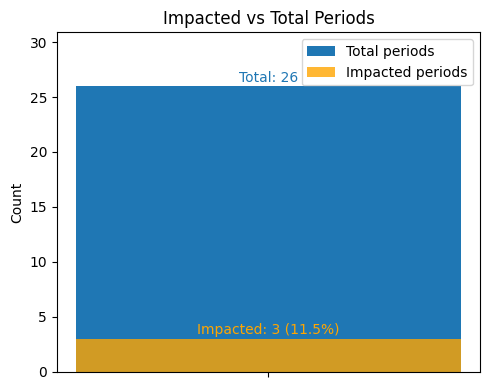

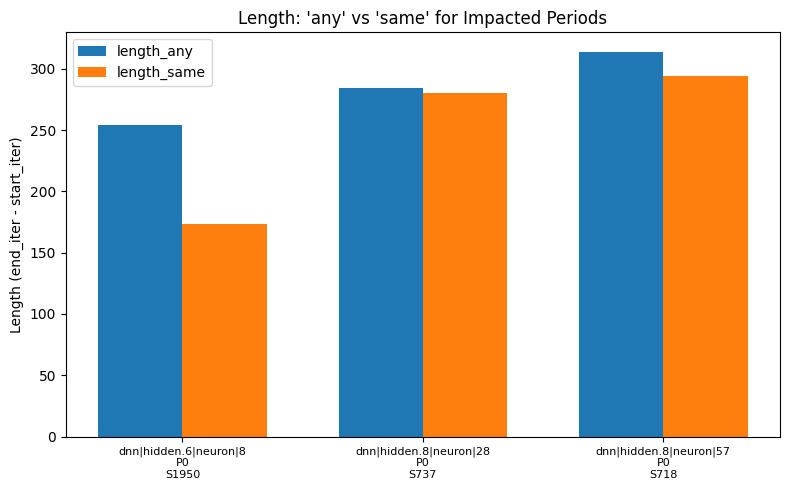

In [9]:
def find_impacted_periods(periods_mode_any: pd.DataFrame, periods_mode_same: pd.DataFrame, return_PRINT = False):
	"""
	Find periods that are impacted by the mode change.
	"""
	a,s = periods_mode_any.set_index(["neuron_id", "period_id", "start_iter"]), periods_mode_same.set_index(["neuron_id", "period_id", "start_iter"])
	# a and s should have the same periods - though their end might differ (since the start is only defined by the dead -> assigned event)
	assert a.index.equals(s.index)
	impacted_mask = a["end_iter"] != s["end_iter"]
	a_impacted = a[impacted_mask]
	s_impacted = s[impacted_mask]
	if return_PRINT:
		print(f"The impacted periods are:")
		print(f"  neuron_id, period_id, start_iter")
		for i, row in a_impacted.iterrows():
			print(f"  {i}")
			print(f"    Any: {row['end_iter']} vs Same: {s_impacted.loc[i]['end_iter']}")
		return None
	else:
		joined = a_impacted.join(s_impacted, lsuffix="_any", rsuffix="_same")
		impacted = joined.drop(columns=[c for c in joined.columns if not (c.startswith("end_iter"))])
		# print(f"Impacted")
		# display(impacted.head(20))
		return impacted

def maybe_plot(impacted: pd.DataFrame | None, num_periods:int):
	if impacted is None:
		return

	# Plot 1: Overlapping bar graph showing the proportion of impacted/total periods
	fig, ax = plt.subplots(figsize=(5,4))
	n_impacted = len(impacted)
	prop = n_impacted / num_periods if num_periods else 0
	x = np.arange(1)
	ax.bar(x, [num_periods], width=0.4, label="Total periods")
	ax.bar(x, [n_impacted], width=0.4, label="Impacted periods", alpha=0.8, color='orange')
	ax.set_ylim(0, max(num_periods, n_impacted)*1.15+1)
	ax.set_xticks(x)
	ax.set_xticklabels([''])
	ax.set_ylabel('Count')
	ax.set_title('Impacted vs Total Periods')
	ax.legend()
	ax.text(0, num_periods+0.1, f'Total: {num_periods}', ha='center', va='bottom', color='tab:blue')
	ax.text(0, n_impacted+0.1, f'Impacted: {n_impacted} ({prop:.1%})', ha='center', va='bottom', color='orange')
	plt.tight_layout()
	plt.show()

	# Plot 2: Bar graph for each neuron/period start, two bars ("any", "same") on x-axis
	# Prepare x-ticks as labels: "neuron|period|start_iter"
	x_labels = [f"{idx[0]}\nP{idx[1]}\nS{idx[2]}" for idx in impacted.index]
	x = np.arange(len(impacted))
	width = 0.35

	# Compute lengths: end_iter - start_iter for both "any" and "same" modes (start_iter is in the index)
	start_iters = [idx[2] for idx in impacted.index]
	length_any = impacted["end_iter_any"].values - np.array(start_iters)
	length_same = impacted["end_iter_same"].values - np.array(start_iters)

	fig, ax = plt.subplots(figsize=(max(8, len(x_labels)*0.7), 5))
	ax.bar(x - width/2, length_any, width, label="length_any")
	ax.bar(x + width/2, length_same, width, label="length_same")
	ax.set_xticks(x)
	ax.set_xticklabels(x_labels, ha='center', fontsize=8)
	ax.set_ylabel("Length (end_iter - start_iter)")
	ax.set_title("Length: 'any' vs 'same' for Impacted Periods")
	ax.legend()
	plt.tight_layout()
	plt.show()

PLOT_IMPACTED = True

maybe_plot(find_impacted_periods(recovery_periods_any, recovery_periods_same, return_PRINT=not PLOT_IMPACTED),len(recovery_periods_any))
	


### 1.1 Select period-identification strategy

#### 1.1.1 Lengths

We have two period-identification strategies to identify the length of a period: `assigned_any` and `assigned_same`. They are both documented in the  `get_recovery_periods()` function. In short:

**assigned_any**: For each neuron, we qualify only periods in training where 
* the neuron is originally dead
* the neuron becomes assigned to a (set of) digit(s) 

The period stop whenever the neuron is not assigned to any digit anymore (but it can still be partially active).

This "resets" whenever the neuron dies again (aka not _active_ for any sample of any digits)
	
**assigned_same**: For each neuron, we qualify only periods in training where 
* the neuron is originally dead
* the neuron becomes assigned to a (set of) digit(s) D

The period stop whenever the neuron is not assigned to the any of the digits in D anymore.

This "resets" whenever the neuron dies again (aka not _active_ for any sample of any digits)


In [10]:
recovery_periods = recovery_periods_same # or recovery_periods_any
display(recovery_periods.head(30))

,neuron_id,layer_name,period_id,start,end,start_iter,end_iter,total_length_iter
0,dnn|hidden.2|neuron|19,hidden.2,0,1062,1945.0,1051,1925,874
1,dnn|hidden.2|neuron|42,hidden.2,0,2335,2559.0,2311,2533,222
2,dnn|hidden.4|neuron|10,hidden.4,0,2334,2439.0,2310,2414,104
3,dnn|hidden.4|neuron|20,hidden.4,0,1230,1335.0,1217,1321,104
4,dnn|hidden.4|neuron|43,hidden.4,0,1433,1560.0,1418,1544,126
5,dnn|hidden.4|neuron|46,hidden.4,0,1085,1234.0,1074,1221,147
6,dnn|hidden.4|neuron|46,hidden.4,1,2567,NaN,2541,3000,459
7,dnn|hidden.4|neuron|52,hidden.4,0,1560,1630.0,1544,1613,69
8,dnn|hidden.6|neuron|16,hidden.6,0,1277,1319.0,1264,1305,41
9,dnn|hidden.6|neuron|38,hidden.6,0,1067,1222.0,1056,1209,153


In [11]:
def get_period_data(recovery_periods,neuron_id:str,period_id: int| None = None):
	# Access the recpvery_period data. It is possible that the neuron_id has only one period. In that case, allow period_id to be None and return it
	neuron_data = recovery_periods.set_index(["neuron_id","period_id"]).loc[neuron_id]
	if period_id is None:
		if len(neuron_data) == 1:
			return neuron_data.iloc[0] # iloc because it is possible that filtering removes the period with id 0 -> loc 0 would be incorrect
		else:
			raise ValueError(f"Neuron {neuron_id} has {len(neuron_data)} periods. Please specify the period_id.")
	else:
		return neuron_data.loc[period_id]

##### Rmove ineligible periods 

Remove the identified BTSP events that do not last until at least the end of their trial


In [12]:
def get_trial_start_end_iter(start_iter,start: bool = True):
	return ((start_iter // N_SAMPLES_PER_TRIAL)+(0 if start else 1))*N_SAMPLES_PER_TRIAL

def remove_inelligible_periods(recovery_periods):
	"""
	Remove periods that do not last until the end of their trial.
	"""
	to_remove = recovery_periods[recovery_periods["end_iter"] < get_trial_start_end_iter(recovery_periods["start_iter"],start=False)]
	print(f"Removing {len(to_remove)} period(s) that do not last until the end of their trial.")
	if len(to_remove) > 0:
		for i, row in to_remove.iterrows():
			print(f"Removing: {row}\n")
	return recovery_periods.drop(to_remove.index)

recovery_periods = remove_inelligible_periods(recovery_periods)

Removing 1 period(s) that do not last until the end of their trial.
Removing: neuron_id            dnn|hidden.8|neuron|49
layer_name                         hidden.8
period_id                                 0
start                                  1019
end                                  1037.0
start_iter                             1008
end_iter                               1026
total_length_iter                        18
Name: 22, dtype: object



#### 1.1.2 BTSP "start"

We have too strategies to identify the true "start" of a BTSP 

In [13]:
index_grp = ["neuron_id", "period_id"]

In [14]:
def get_trial_starts(recovery_periods, neuron_id:str, period_id: int|None = None):
	period_data = get_period_data(recovery_periods,neuron_id,period_id)
	trial_start_iter = get_trial_start_end_iter(period_data["start_iter"],start=True)
	delta = period_data["start_iter"] - trial_start_iter
	start_cp = period_data["start"] - delta
	return trial_start_iter, delta, start_cp

def get_trial_neuron_activations(nts, recovery_periods, neuron_id:str, period_id: int|None = None, surrounding_n_trials: tuple[int,int] | None = None):
	# nts data is indexed by checkpoint -> find the start checkpoint first
	_,_,start_cp = get_trial_starts(recovery_periods,neuron_id,period_id)
	if surrounding_n_trials is None:
		surrounding_n_trials = (0,0)
	activations = nts["act__"+neuron_id][start_cp-surrounding_n_trials[0]*N_SAMPLES_PER_TRIAL:start_cp + N_SAMPLES_PER_TRIAL + surrounding_n_trials[1]*N_SAMPLES_PER_TRIAL] # Shape (100,50)
	return activations

In [15]:
def get_assigned_digits_for_trial_activations(recovery_periods,neuron_id,period_id):
	trial_activations = get_trial_neuron_activations(nts,recovery_periods,neuron_id,period_id,surrounding_n_trials=(0,0))
	_, delta, _ = get_trial_starts(recovery_periods,neuron_id,period_id)
	active_samples_at_threshold = (trial_activations[delta] > 0).reshape((_NETWORK_N_DIGITS,_NETWORK_SAMPLES_PER_DIGIT)) # shape (10,5)
	assigned_digits = active_samples_at_threshold.all(axis=1) # shape (10,)
	assert assigned_digits.sum() >= 1
	assigned_digits = np.argwhere(assigned_digits).flatten()
	assert all(maybe_assigned == (d in assigned_digits) for d,maybe_assigned in enumerate(np.all(active_samples_at_threshold,axis=1)))
	return assigned_digits

In [16]:
def get_last_inactive_samples_indices(nts,recovery_periods,neuron_id,period_id):
	trial_activations = get_trial_neuron_activations(nts,recovery_periods,neuron_id,period_id,surrounding_n_trials=(0,0))
	_, delta, _ = get_trial_starts(recovery_periods,neuron_id,period_id)
	assigned_digits = get_assigned_digits_for_trial_activations(recovery_periods,neuron_id,period_id)
	
	active_samples_before_threshold = (trial_activations[delta-1] > 0).reshape((_NETWORK_N_DIGITS,_NETWORK_SAMPLES_PER_DIGIT))
	samples_for_active_digits = active_samples_before_threshold[assigned_digits,:] # shape (k,5)
	assert not all(maybe_assigned for maybe_assigned in np.all(samples_for_active_digits,axis=1))
	last_inactive_samples = np.argmax(~samples_for_active_digits,axis=1) # shape (k,)
	indices = [d * _NETWORK_SAMPLES_PER_DIGIT + sample for d,sample in zip(assigned_digits,last_inactive_samples)]
	if len(indices) > 1:
		print(f"more than 1 for {neuron_id} {period_id}: {indices=}")
	return indices


In [17]:
def point_of_max_acceleration(nts,recovery_periods,neuron_id,period_id):
	trial_activations = get_trial_neuron_activations(nts,recovery_periods,neuron_id,period_id,surrounding_n_trials=(0,0))
	_, delta, _ = get_trial_starts(recovery_periods,neuron_id,period_id)
	derivative = np.diff(trial_activations,axis=0) # shape (99,50)
	second_derivative = np.diff(derivative,axis=0) # shape (98,50)
	
	assigned_digits = get_assigned_digits_for_trial_activations(recovery_periods,neuron_id,period_id)
	indices_to_keep = np.concatenate([d*_NETWORK_SAMPLES_PER_DIGIT + np.arange(_NETWORK_SAMPLES_PER_DIGIT) for d in assigned_digits])
	# Keep all the accelerations since the trial start until the threshold (`-2` because we want the second derivative at the sample *just BEFORE* the threshold)
	# and only those for the samples of the digits activated at the threshold
	accelerations_to_consider = second_derivative[0:delta-2,indices_to_keep] # shape (time,k)
	acceleration_peak = np.argmax(accelerations_to_consider,axis=0) # shape (k,)
	# one index 5 samples per digit, keep the earliest one of all ; `+2` to go back to activation index space
	return np.min(acceleration_peak)+2

In [18]:
point_of_max_acceleration(nts,recovery_periods,"dnn|hidden.4|neuron|52",0)

np.int64(19)

In [19]:
def get_all_points_of_max_acceleration(nts,recovery_periods):
	columns_to_keep = index_grp + ["start_iter"]
	ret = (recovery_periods.drop(columns={c for c in recovery_periods.columns if c not in columns_to_keep})\
		.assign(point_of_max_acceleration=lambda df: df\
			.apply(lambda row: point_of_max_acceleration(nts,recovery_periods,row["neuron_id"],row["period_id"]),axis=1))\
		.set_index(index_grp))
	ret["delay_from_trial_start"] = ret["start_iter"].apply(lambda x: x%N_SAMPLES_PER_TRIAL)
	ret = ret.drop(columns=["start_iter"])
	return ret

points_of_max_acceleration = get_all_points_of_max_acceleration(nts,recovery_periods)

In [20]:
def plot_all_points_of_max_acceleration(points_of_max_acceleration):
	df_reset = points_of_max_acceleration.reset_index()
	df_reset["proximity_to_assignment_pct"] = ( df_reset["point_of_max_acceleration"]/df_reset["delay_from_trial_start"] * 100)
	df_reset = df_reset.sort_values(by="proximity_to_assignment_pct")	
	fig, axs = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [1, 2]})
	
	# --- First plot: Boxplot of point_of_max_acceleration
	axs[0].boxplot(df_reset["point_of_max_acceleration"].values, vert=True, patch_artist=True, showmeans=True, showfliers=True)
	axs[0].set_ylabel("Point of Max Acceleration")
	axs[0].set_title("Distribution of Point of Max Acceleration Across All Periods")
	axs[0].set_xticks([])	
	df_reset["period_label"] = df_reset["neuron_id"].astype(str) + "|p" + df_reset["period_id"].astype(str)
	bar_width = 0.4
	x = np.arange(len(df_reset["period_label"]))
	
	# First set of bars: proximity_to_assignment_pct
	bars1 = axs[1].bar(x - bar_width/2, df_reset["proximity_to_assignment_pct"], width=bar_width, color='tab:blue', alpha=0.7, label='Proximity to Assignment (%)')
	# Second set of bars: absolute point_of_max_acceleration
	bars2 = axs[1].bar(x + bar_width/2, df_reset["point_of_max_acceleration"], width=bar_width, color='tab:orange', alpha=0.7, label='Point of Max Acceleration')
	
	axs[1].set_ylabel("Proximity / Point of Max Acceleration")
	axs[1].set_title("Proximity to Assignment and Point of Max Acceleration Per Period")
	axs[1].set_xticks(x)
	axs[1].set_xticklabels(df_reset["period_label"], rotation=85, fontsize=7)
	axs[1].set_xlabel("Period (neuron_id|period_id)")
	axs[1].legend()
	
	# Annotate values above both sets of bars
	for bar, label in zip(bars1, df_reset["proximity_to_assignment_pct"]):
		height = bar.get_height()
		axs[1].annotate(f'{label:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
			xytext=(0, 3),  # 3 points vertical offset
			textcoords="offset points",
			ha='center', va='bottom', fontsize=6)
	for bar, label in zip(bars2, df_reset["point_of_max_acceleration"]):
		height = bar.get_height()
		axs[1].annotate(f'{label:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
			xytext=(0, 3),  # 3 points vertical offset
			textcoords="offset points",
			ha='center', va='bottom', fontsize=6)

	plt.tight_layout()
	plt.show()

In [21]:
points_of_max_acceleration

point_of_max_acceleration  \
neuron_id              period_id                              
dnn|hidden.2|neuron|19 0                                  4   
dnn|hidden.2|neuron|42 0                                 10   
dnn|hidden.4|neuron|10 0                                  2   
dnn|hidden.4|neuron|20 0                                  4   
dnn|hidden.4|neuron|43 0                                 13   
dnn|hidden.4|neuron|46 0                                  4   
                       1                                  6   
dnn|hidden.4|neuron|52 0                                 19   
dnn|hidden.6|neuron|16 0                                  4   
dnn|hidden.6|neuron|38 0                                  3   
                       1                                 16   
dnn|hidden.6|neuron|8  0                                  4   
dnn|hidden.8|neuron|15 0                                  2   
dnn|hidden.8|neuron|22 0                                  3   
dnn|hidden.8|neuron|26 0                                 18   
                       1                                  3   
dnn|hidden.8|neuron|28 0                                  2   
dnn|hidden.8|neuron|29 0                                  3   
                       1                                 10   
dnn|hidden.8|neuron|42 0                                  2   
                       1                                  4   
dnn|hidden.8|neuron|48 0                                 17   
dnn|hidden.8|neuron|49 1                                  9   
dnn|hidden.8|neuron|57 0                                  2   
                       1                                  3   

                                  delay_from_trial_start  
neuron_id              period_id                          
dnn|hidden.2|neuron|19 0                              51  
dnn|hidden.2|neuron|42 0                              11  
dnn|hidden.4|neuron|10 0                              10  
dnn|hidden.4|neuron|20 0                              17  
dnn|hidden.4|neuron|43 0                              18  
dnn|hidden.4|neuron|46 0                              74  
                       1                              41  
dnn|hidden.4|neuron|52 0                              44  
dnn|hidden.6|neuron|16 0                              64  
dnn|hidden.6|neuron|38 0                              56  
                       1                              57  
dnn|hidden.6|neuron|8  0                              50  
dnn|hidden.8|neuron|15 0                              56  
dnn|hidden.8|neuron|22 0                              25  
dnn|hidden.8|neuron|26 0                              43  
                       1                              36  
dnn|hidden.8|neuron|28 0                              37  
dnn|hidden.8|neuron|29 0                              30  
                       1                              48  
dnn|hidden.8|neuron|42 0                              19  
                       1                              19  
dnn|hidden.8|neuron|48 0                              25  
dnn|hidden.8|neuron|49 1                              25  
dnn|hidden.8|neuron|57 0                              18  
                       1                              56

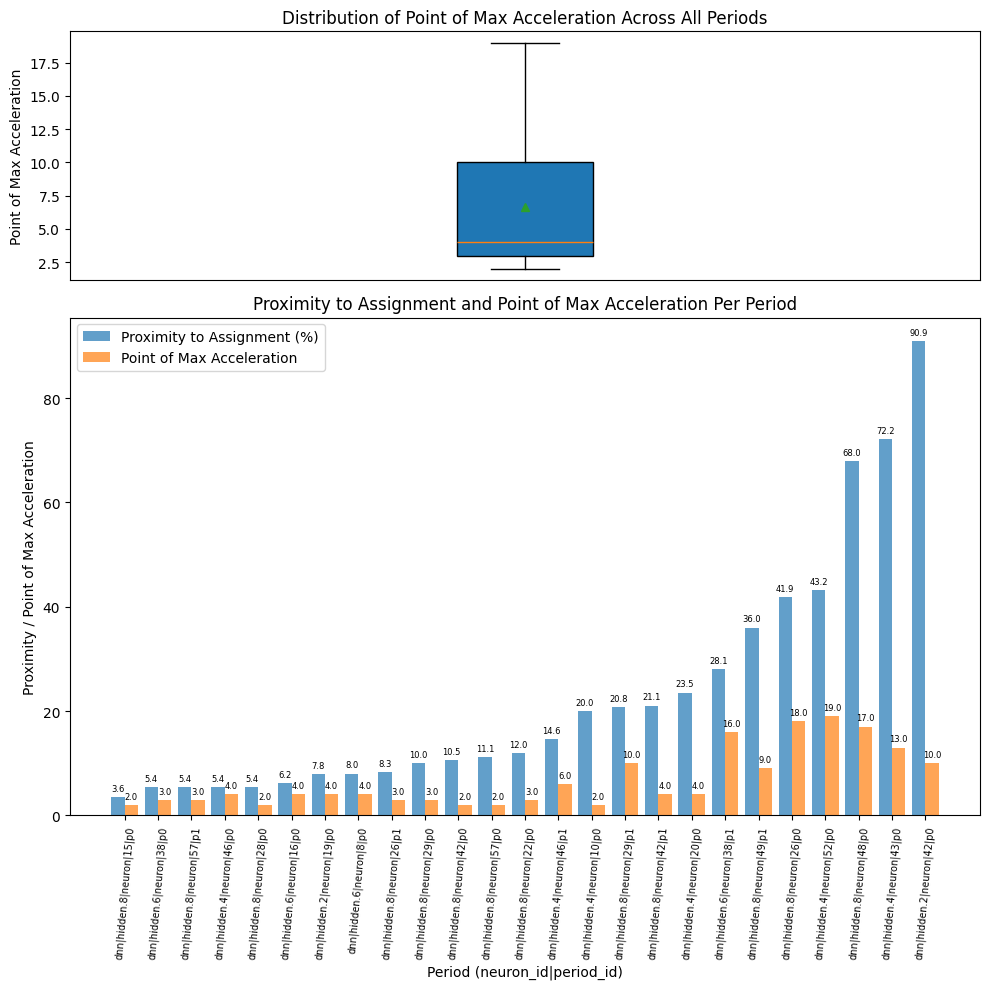

In [22]:
plot_all_points_of_max_acceleration(points_of_max_acceleration)

In [23]:
BTSP_START_STRATEGY = "acceleration" # or "trial_start"

## 1.2 Filter periods

We have the choice to be "strict" with regards to the kept periods in a sense that a BTSP event should technically only occur iff the neuron is completely dead at the start of the trial. This would, however, remove most such periods.

In [24]:
def filter_periods(recovery_periods, strict = False):
	"""
	Filter periods for cps that are not dead at some point in the trial before the period starts.
	"""
	trial_starts = recovery_periods[["start_iter","neuron_id","period_id"]].assign(trial_start=lambda df: df["start_iter"].map(get_trial_start_end_iter))
	mrgd = df_dead.merge(trial_starts,left_on=["neuron_id","iteration"],right_on=["neuron_id","trial_start"],how="inner")[["neuron_id","period_id","is_dead"]]
	if strict:
		return recovery_periods.loc[mrgd[mrgd["is_dead"]].index]
	else:
		print(f"Keeping recovery periods that are not dead at some point during that trial where the recovery occurs. \n Would've removed {(~mrgd['is_dead']).sum()}/{len(mrgd)} period(s) otherwise.")
		return recovery_periods

STRICT = False
recovery_periods = filter_periods(recovery_periods,strict=STRICT)

Keeping recovery periods that are not dead at some point during that trial where the recovery occurs. 
 Would've removed 19/25 period(s) otherwise.


## 2. Gather period information

We've now identified candidate BTSP events. We must gather some information in order to better characterize them.

### 2.1 One-Shot-ness

In [25]:
point_of_max_acceleration(nts,recovery_periods,"dnn|hidden.8|neuron|29",1)

np.int64(10)

In [26]:
def get_period_angles(nts,recovery_periods,from_point:str = "acceleration", use_real_progression = True):
	"""
	from_point: "trial_start" or "acceleration" : decides whether to use the start of the trial, or the point of highest acceleration as reference for the angle calculation
	"""
	if from_point not in {"trial_start","acceleration"}:
		raise ValueError(f"from_point must be one of {{'trial_start','acceleration'}}, got {from_point}")
	def get_activation_angle(neuron_id,period_id):
		activations = get_trial_neuron_activations(nts,recovery_periods,neuron_id,period_id)
		assert len(activations) == N_SAMPLES_PER_TRIAL
		_, delta, _ = get_trial_starts(recovery_periods,neuron_id,period_id)
		if from_point == "trial_start" :
			activation_at_start_of_trial = activations[0]
			reference_activation = activation_at_start_of_trial
			reference_delta = delta
		else:
			assert from_point == "acceleration"
			trial_index_of_max_acceleration = point_of_max_acceleration(nts,recovery_periods,neuron_id,period_id)
			assert trial_index_of_max_acceleration <= delta
			reference_activation = activations[trial_index_of_max_acceleration]
			reference_delta = delta - trial_index_of_max_acceleration
		activation_at_assignment = activations[delta]
		angles = np.degrees(np.arctan2(activation_at_assignment-reference_activation,reference_delta if use_real_progression else 1)) # shape (50,)
		last_inactive_sample_indices = get_last_inactive_samples_indices(nts,recovery_periods,neuron_id,period_id)
		return np.max(angles[last_inactive_sample_indices])


	period_angles = recovery_periods.drop(columns={c for c in recovery_periods.columns if c not in index_grp}).assign(activation_angle=lambda df: df.apply(lambda row: get_activation_angle(row["neuron_id"],row["period_id"]),axis=1)).set_index(index_grp)
	return period_angles

REFERENCE_POINT = BTSP_START_STRATEGY # "trial_start" or "acceleration"
USE_REAL_PROGRESSION = True

period_angles = get_period_angles(nts,recovery_periods,from_point=REFERENCE_POINT,use_real_progression=USE_REAL_PROGRESSION)
display(period_angles.head(20))

activation_angle
neuron_id              period_id                  
dnn|hidden.2|neuron|19 0                  2.280570
dnn|hidden.2|neuron|42 0                  0.491616
dnn|hidden.4|neuron|10 0                  0.033716
dnn|hidden.4|neuron|20 0                  6.906849
dnn|hidden.4|neuron|43 0                  0.969324
dnn|hidden.4|neuron|46 0                  3.098275
                       1                  1.842651
dnn|hidden.4|neuron|52 0                  2.362023
dnn|hidden.6|neuron|16 0                  2.588796
dnn|hidden.6|neuron|38 0                  0.799152
                       1                  0.893810
dnn|hidden.6|neuron|8  0                  0.449996
dnn|hidden.8|neuron|15 0                  1.373213
dnn|hidden.8|neuron|22 0                  2.048089
dnn|hidden.8|neuron|26 0                  0.496531
                       1                  1.592454
dnn|hidden.8|neuron|28 0                  1.798790
dnn|hidden.8|neuron|29 0                  0.429780
                       1                  3.116625
dnn|hidden.8|neuron|42 0                  1.585296

In [27]:
def show_activations_of_trial(nts,recovery_periods,neuron_id: str,period_id: int | None = None):
	trial_start_iter, delta, _ = get_trial_starts(recovery_periods,neuron_id,period_id)
	activations = get_trial_neuron_activations(nts,recovery_periods,neuron_id,period_id,surrounding_n_trials=(1,0))

	
	x_full = np.arange(len(activations)).astype(np.float64)
	x_deriv = x_full[:-1] + 0.5  
	x_2nd_deriv = x_full[:-2] + 1.0
	
	derivative = np.diff(activations.astype(np.float64), axis=0)  # Shape (99, 50)
	second_derivative = np.diff(derivative, axis=0)  # Shape (98, 50)
	
	true_iterations = trial_start_iter - N_SAMPLES_PER_TRIAL + x_full
	dx_iter = np.diff(true_iterations.astype(np.float64))
	angle_deg = np.degrees(np.arctan2(derivative, dx_iter[:, np.newaxis]))  # signed slope; matches mpl_neuron_eval_activation_angle_over_time
	
	vline_x = delta + N_SAMPLES_PER_TRIAL
	
	# Create figure with GridSpec
	n_rows, n_cols = 5, 2
	n_plots_per_digit = 4
	fig = plt.figure(figsize=(20, 24))
	gs = GridSpec(
		n_rows * n_plots_per_digit,
		n_cols,
		figure=fig,
	)
	
	# Plot for each digit
	for d in range(_NETWORK_N_DIGITS):
		row_idx = d // n_cols
		col_idx = d % n_cols
		
		# Extract activations for this digit (K=5 samples)
		start_col = d * _NETWORK_SAMPLES_PER_DIGIT
		end_col = start_col + _NETWORK_SAMPLES_PER_DIGIT
		digit_act = activations[:, start_col:end_col]
		digit_deriv = derivative[:, start_col:end_col]
		digit_angle = angle_deg[:, start_col:end_col]
		digit_2nd_deriv = second_derivative[:, start_col:end_col]
		
		# Create four subplots for this digit (stacked vertically)
		ax_act = fig.add_subplot(gs[row_idx * 4, col_idx])
		ax_deriv = fig.add_subplot(gs[row_idx * 4 + 1, col_idx])
		ax_angle = fig.add_subplot(gs[row_idx * 4 + 2, col_idx])
		ax_2nd_deriv = fig.add_subplot(gs[row_idx * 4 + 3, col_idx])
		
		# Plot traces for each of K=5 samples
		for k in range(_NETWORK_SAMPLES_PER_DIGIT):
			color = _NETWORK_EVAL_K_LINE_COLORS[k % len(_NETWORK_EVAL_K_LINE_COLORS)]
			label = f"K={k + 1}"
			
			# Activation
			ax_act.plot(
				x_full,
				digit_act[:, k],
				color=color,
				linewidth=1.25,
				marker=".",
				markersize=3,
				label=label,
				alpha=0.8,
			)
			
			# Derivative
			ax_deriv.plot(
				x_deriv,
				digit_deriv[:, k],
				color=color,
				linewidth=1.25,
				marker=".",
				markersize=3,
				label=label,
				alpha=0.8,
			)
			
			# Signed angle atan2(da, diter) per segment (same convention as mpl_neuron_eval_activation_angle_over_time)
			ax_angle.plot(
				x_full[1:],
				digit_angle[:, k],
				color=color,
				linewidth=1.25,
				marker=".",
				markersize=3,
				label=label,
				alpha=0.8,
			)
			
			# Second derivative
			ax_2nd_deriv.plot(
				x_2nd_deriv,
				digit_2nd_deriv[:, k],
				color=color,
				linewidth=1.25,
				marker=".",
				markersize=3,
				label=label,
				alpha=0.8,
			)
		
		# Add vertical dashed line at delta for all four subplots
		for ax in [ax_act, ax_deriv, ax_angle, ax_2nd_deriv]:
			ax.axvline(vline_x, color="black", linestyle="--", linewidth=1.5, alpha=0.6, zorder=1)
			ax.axhline(0.0, color=C["border"], linewidth=0.8, linestyle="-", zorder=0)
			ax.grid(True, color=C["grid"], linestyle="-", linewidth=0.8, alpha=0.6)
			ax.set_facecolor("white")
			for spine in ax.spines.values():
				spine.set_color(C["border"])
			ax.tick_params(colors=C["fg"], labelsize=8)
		
		# Titles for activation subplot (top of each digit column)
		ax_act.set_title(f"Digit {d}", fontsize=11, color=C["fg"], pad=12, fontweight="bold")
		
		# Y-axis labels
		ax_act.set_ylabel("Activation", fontsize=9, color=C["fg"])
		ax_act.set_facecolor("#f0f0f0")
		ax_act.axhline(0.0, color=C["red"], linewidth=0.8, linestyle="-", zorder=0)
		ax_deriv.set_ylabel("dA/dt", fontsize=9, color=C["fg"])
		ax_angle.set_ylabel("Signed angle (°)", fontsize=9, color=C["fg"])
		ax_angle.set_ylim(-10,10)
		ax_2nd_deriv.set_ylabel("d²A/dt²", fontsize=9, color=C["fg"])
		
		# X-axis labels (only for bottom row) - set to true iteration values
		# if row_idx == n_rows - 1:
		# Set x-ticks and labels to true iterations
		tick_indices = np.linspace(0, len(activations) - 1, 5, dtype=int)
		tick_labels = [str(int(true_iterations[i])) for i in tick_indices]
		def set_tick_labels(ax,tick_indices,tick_labels):
			ax.set_xticks(tick_indices)
			ax.set_xticklabels(tick_labels, fontsize=8)
		set_tick_labels(ax_2nd_deriv,tick_indices,tick_labels)
		set_tick_labels(ax_deriv,tick_indices,tick_labels)
		set_tick_labels(ax_angle,tick_indices,tick_labels)
		set_tick_labels(ax_act,tick_indices,tick_labels)
		ax_2nd_deriv.set_xlabel("Iteration", fontsize=9, color=C["fg"])
		
		# Remove x-tick labels for non-bottom rows
		# if row_idx < n_rows - 1:
		# 	ax_act.set_xticklabels([])
		# 	ax_deriv.set_xticklabels([])
		# 	ax_angle.set_xticklabels([])
		# 	ax_2nd_deriv.set_xticklabels([])
		
		# Legend only on first digit
		if d == 0:
			ax_act.legend(
				loc="upper right",
				fontsize=8,
				framealpha=0.92,
				edgecolor=C["border"],
				ncol=1,
			)
	start_iter,_,_ = get_trial_starts(recovery_periods,neuron_id,period_id)
	fig.suptitle(
		f"Activation Analysis: {_compact_neuron_label(neuron_id)} (Trial from iter {start_iter})",
		fontsize=13,
		color=C["fg"],
		fontweight="bold",
	)
	fig.patch.set_facecolor("white")
	
	fig.tight_layout()
	
	return fig

In [28]:
PLOT = False
if PLOT:
	show_activations_of_trial(nts,recovery_periods,neuron_id="dnn|hidden.4|neuron|20",period_id=0)

f(2)=0.022, f(10)=0.500, f(90)=1.000


/tmp/ipykernel_524429/2105638821.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


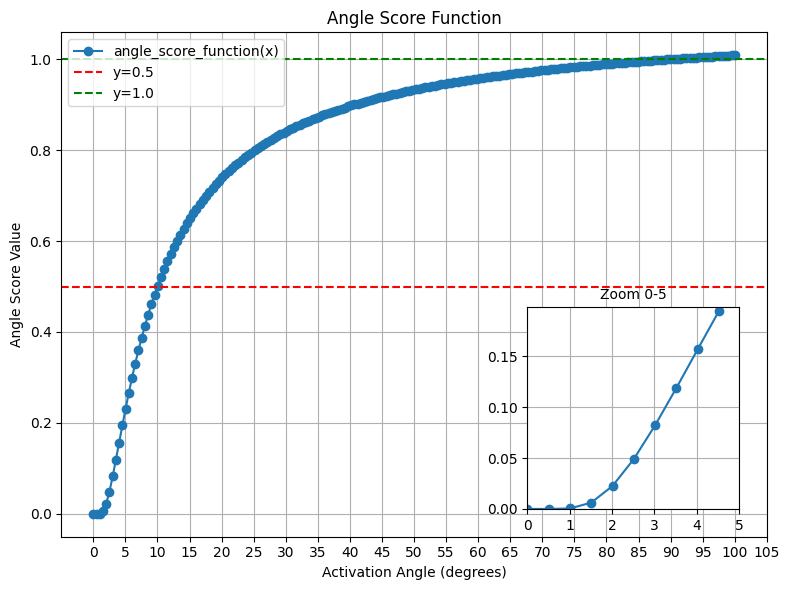

In [29]:
def angle_score_function(x):
	# f(x) = s * e^(-k/x) such that f(10) = 0.5 and f(90) = 1
	angle_at_0_5 = 10
	angle_at_1 = 90
	s = 2**((angle_at_0_5)/(angle_at_1-angle_at_0_5))
	k = angle_at_0_5*np.log(2*s)
	return s * np.exp(-k/x)

print(f"f(2)={angle_score_function(2):.3f}, f(10)={angle_score_function(10):.3f}, f(90)={angle_score_function(90):.3f}")

x = np.linspace(0.001, 100, 200)
y = np.array([angle_score_function(xi) for xi in x])

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(x, y, marker='o', label="angle_score_function(x)")

ax.axhline(0.5, color="red", linestyle="--", label="y=0.5")
ax.axhline(1.0, color="green", linestyle="--", label="y=1.0")
ax.set_xlabel("Activation Angle (degrees)")
ax.set_ylabel("Angle Score Value")
ax.set_title("Angle Score Function")
ax.legend(loc="upper left")
ax.grid(True)
ax.set_xticks(np.arange(0, 110, 5))

axins = inset_axes(ax, width="30%", height="40%", loc="lower right", borderpad=2)
axins.plot(x, y, marker='o')
axins.axhline(0.5, color="red", linestyle="--")
axins.axhline(1.0, color="green", linestyle="--")

x_zoom_idx = (x >= 0) & (x <= 5)
y_zoom = y[x_zoom_idx]
x_zoom = x[x_zoom_idx]

# Set limits for zoomed region
ymin = min(y_zoom) * 0.98
ymax = max(y_zoom) * 1.02
axins.set_xlim(0, 5)
axins.set_ylim(ymin, ymax)
axins.set_xticks(np.arange(0, 6, 1))
axins.set_title("Zoom 0-5", fontsize=10)
axins.grid(True)
plt.tight_layout()
plt.show()

In [30]:
angles_scores = period_angles.assign(angle_score=lambda df: df["activation_angle"].apply(angle_score_function)).drop(columns={"activation_angle"})
angles_scores.head(20)

angle_score
neuron_id              period_id               
dnn|hidden.2|neuron|19 0           3.569890e-02
dnn|hidden.2|neuron|42 0           1.409127e-07
dnn|hidden.4|neuron|10 0          3.924074e-101
dnn|hidden.4|neuron|20 0           3.526190e-01
dnn|hidden.4|neuron|43 0           3.498383e-04
dnn|hidden.4|neuron|46 0           8.801830e-02
                       1           1.583944e-02
dnn|hidden.4|neuron|52 0           4.016639e-02
dnn|hidden.6|neuron|16 0           5.363619e-02
dnn|hidden.6|neuron|38 0           6.308138e-05
                       1           1.772940e-04
dnn|hidden.6|neuron|8  0           3.249477e-08
dnn|hidden.8|neuron|15 0           3.727788e-03
dnn|hidden.8|neuron|22 0           2.421552e-02
dnn|hidden.8|neuron|26 0           1.648685e-07
                       1           8.146696e-03
dnn|hidden.8|neuron|28 0           1.428649e-02
dnn|hidden.8|neuron|29 0           1.438176e-08
                       1           8.933232e-02
dnn|hidden.8|neuron|42 0           7.968557e-03

### 2.2 Activation sustainment

In [31]:
recovery_periods.head(20)

,neuron_id,layer_name,period_id,start,end,start_iter,end_iter,total_length_iter
0,dnn|hidden.2|neuron|19,hidden.2,0,1062,1945.0,1051,1925,874
1,dnn|hidden.2|neuron|42,hidden.2,0,2335,2559.0,2311,2533,222
2,dnn|hidden.4|neuron|10,hidden.4,0,2334,2439.0,2310,2414,104
3,dnn|hidden.4|neuron|20,hidden.4,0,1230,1335.0,1217,1321,104
4,dnn|hidden.4|neuron|43,hidden.4,0,1433,1560.0,1418,1544,126
5,dnn|hidden.4|neuron|46,hidden.4,0,1085,1234.0,1074,1221,147
6,dnn|hidden.4|neuron|46,hidden.4,1,2567,NaN,2541,3000,459
7,dnn|hidden.4|neuron|52,hidden.4,0,1560,1630.0,1544,1613,69
8,dnn|hidden.6|neuron|16,hidden.6,0,1277,1319.0,1264,1305,41
9,dnn|hidden.6|neuron|38,hidden.6,0,1067,1222.0,1056,1209,153


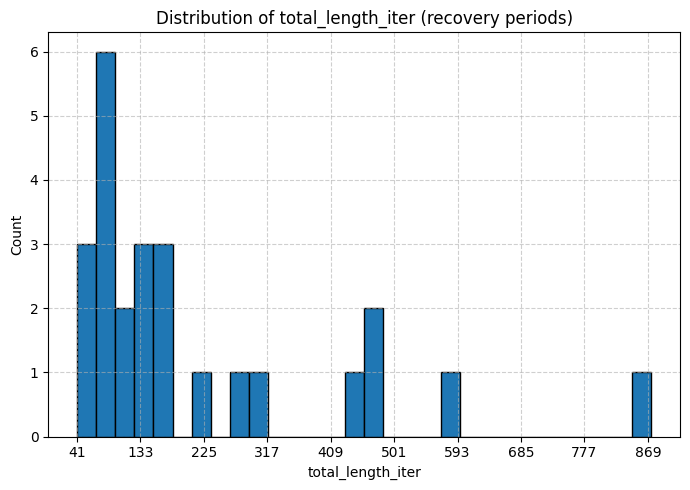

In [32]:
def plot_total_length_iter_distribution(df_periods):
	plt.figure(figsize=(7, 5))
	plt.hist(df_periods["total_length_iter"], bins=30, edgecolor="black")
	plt.xlabel("total_length_iter")
	plt.ylabel("Count")
	plt.title("Distribution of total_length_iter (recovery periods)")
	plt.grid(True, linestyle="--", alpha=0.6)
	ax = plt.gca()
	data = df_periods["total_length_iter"]
	xmin, xmax = data.min(), data.max()
	n_ticks = 10 
	tick_step = max(1, int((xmax - xmin) / (n_ticks - 1)))
	ticks = list(range(int(xmin), int(xmax) + 1, tick_step))
	ax.set_xticks(ticks)

	plt.tight_layout()
	plt.show()

plot_total_length_iter_distribution(recovery_periods)

### 2.3 Feature uniqueness

In [33]:
def get_assignments(df_nd,recovery_periods):
	# For each recovery period, count:
	#   n_assigned_digits  - distinct digits ever "assigned"   to the neuron during [start, end)
	#   n_partial_digits   - distinct digits ever "partial_*"  for the neuron during [start, end)

	# --- 1. Attach period info to every df_nd row (fan-out on neuron_id) ----------
	df_in_period = df_nd.merge(
		recovery_periods[["neuron_id", "period_id", "start", "end"]],
		on="neuron_id",
		how="inner",
	)

	# Keep only rows that belong to [start, end).
	# For open periods (end is NaN) every row from start onward qualifies.
	mask = (df_in_period["checkpoint_idx"] >= df_in_period["start"]) & (
		df_in_period["end"].isna() | (df_in_period["checkpoint_idx"] < df_in_period["end"])
	)
	df_in_period = df_in_period[mask]

	# --- 2. Count distinct digits per status type --------------------------------

	df_at_start = df_in_period[df_in_period["checkpoint_idx"] == df_in_period["start"]]

	n_assigned = (
		df_in_period[df_in_period["status"] == "assigned"]
		.groupby(index_grp)["digit"]
		.nunique()
		.rename("n_assigned_digits_unique")
	)

	n_partial = (
		df_in_period[df_in_period["status"].str.startswith("partial")]
		.groupby(index_grp)["digit"]
		.nunique()
		.rename("n_partial_digits_unique")
	)

	n_assigned_at_start = (
		df_at_start[df_at_start["status"] == "assigned"]
		.groupby(index_grp)["digit"]
		.nunique()
		.rename("n_assigned_at_start")
	)

	n_partial_at_start = (
		df_at_start[df_at_start["status"].str.startswith("partial")]
		.groupby(index_grp)["digit"]
		.nunique()
		.rename("n_partial_at_start")
	)
	

	# --- 3. Join back onto recovery_periods --------------------------------------
	int_cols = ["n_assigned_digits_unique", "n_partial_digits_unique", "n_assigned_at_start", "n_partial_at_start"]
	assignments = (
		n_assigned_at_start.to_frame()
		.join(n_partial_at_start,  on=index_grp)
		.join(n_assigned,         on=index_grp)
		.join(n_partial,          on=index_grp)
		.fillna({c: 0 for c in int_cols})
		.astype({c: int for c in int_cols})
	)
	return assignments

assignments = get_assignments(df_nd,recovery_periods)
display(assignments.head(20))



n_assigned_at_start  n_partial_at_start  \
neuron_id              period_id                                            
dnn|hidden.2|neuron|19 0                            1                   1   
dnn|hidden.2|neuron|42 0                            1                   2   
dnn|hidden.4|neuron|10 0                            1                   2   
dnn|hidden.4|neuron|20 0                            1                   1   
dnn|hidden.4|neuron|43 0                            1                   1   
dnn|hidden.4|neuron|46 0                            1                   2   
                       1                            1                   3   
dnn|hidden.4|neuron|52 0                            1                   2   
dnn|hidden.6|neuron|16 0                            1                   1   
dnn|hidden.6|neuron|38 0                            1                   1   
                       1                            1                   0   
dnn|hidden.6|neuron|8  0                            1                   5   
dnn|hidden.8|neuron|15 0                            1                   0   
dnn|hidden.8|neuron|22 0                            1                   3   
dnn|hidden.8|neuron|26 0                            1                   1   
                       1                            1                   4   
dnn|hidden.8|neuron|28 0                            1                   3   
dnn|hidden.8|neuron|29 0                            1                   2   
                       1                            1                   3   
dnn|hidden.8|neuron|42 0                            1                   2   

                                  n_assigned_digits_unique  \
neuron_id              period_id                             
dnn|hidden.2|neuron|19 0                                 1   
dnn|hidden.2|neuron|42 0                                 1   
dnn|hidden.4|neuron|10 0                                 1   
dnn|hidden.4|neuron|20 0                                 1   
dnn|hidden.4|neuron|43 0                                 1   
dnn|hidden.4|neuron|46 0                                 1   
                       1                                 2   
dnn|hidden.4|neuron|52 0                                 1   
dnn|hidden.6|neuron|16 0                                 1   
dnn|hidden.6|neuron|38 0                                 1   
                       1                                 1   
dnn|hidden.6|neuron|8  0                                 3   
dnn|hidden.8|neuron|15 0                                 1   
dnn|hidden.8|neuron|22 0                                 3   
dnn|hidden.8|neuron|26 0                                 1   
                       1                                 3   
dnn|hidden.8|neuron|28 0                                 5   
dnn|hidden.8|neuron|29 0                                 1   
                       1                                 2   
dnn|hidden.8|neuron|42 0                                 1   

                                  n_partial_digits_unique  
neuron_id              period_id                           
dnn|hidden.2|neuron|19 0                                5  
dnn|hidden.2|neuron|42 0                                5  
dnn|hidden.4|neuron|10 0                                3  
dnn|hidden.4|neuron|20 0                                5  
dnn|hidden.4|neuron|43 0                                3  
dnn|hidden.4|neuron|46 0                                9  
                       1                                9  
dnn|hidden.4|neuron|52 0                                2  
dnn|hidden.6|neuron|16 0                                1  
dnn|hidden.6|neuron|38 0                                3  
                       1                                3  
dnn|hidden.6|neuron|8  0                                6  
dnn|hidden.8|neuron|15 0                                0  
dnn|hidden.8|neuron|22 0                                7  
dnn|hidden.8|n

### 2.4 Representational distance to perfect model

RDX or SSIM

In [34]:
COMPUTATION_POINT = "max_activity" # or "assignment point"
EXPERT_MODEL_DIR = "local/save/expert_optimizer_pretrained/!OPT/"

### 2.x Wieght uniformity?

# Final Scores

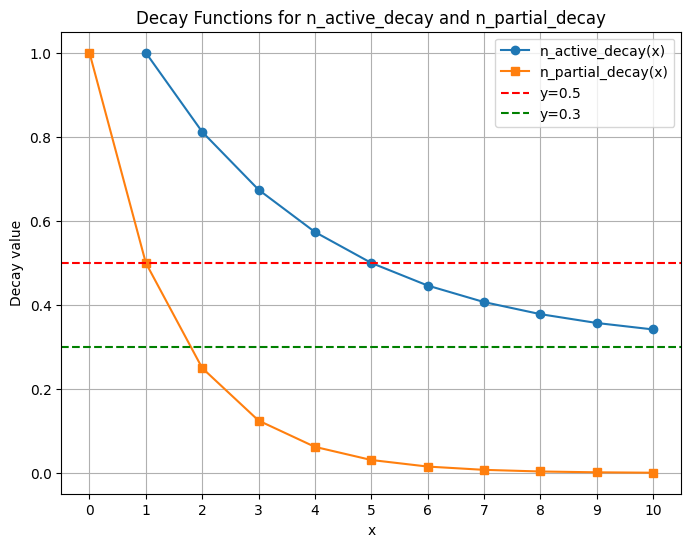

In [35]:
def n_active_decay(x):
	assert x>= 0
	if x == 0:
		raise ValueError("x cannot be 0")
		return 0
	elif x <= 1:
		return 1
	else:
		#                                            ^ 5 == N_DIGITS //2 
		# Exponential decay such that n_active_decay(5) = 0.5 and limit in ifty is `lim`
		lim = 0.3
		scale = np.log(7/2) / 4 # for decay(5) = 0.5
		return lim + np.exp((-(scale*(x-1)-np.log(1-lim))))

def n_partial_decay(x):
	assert x>= 0
	if x == 0:
		return 1
	else:
		# Exponential decay such that n_partial_decay(1) = 0.5
		return np.exp(-np.log(1/0.5)*x)

# --- Plot the functions ------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 200)
# For stepwise/discrete behavior at low x, call the function on ints for display
x_int = np.arange(0, 11)

y_active = np.array([n_active_decay(xi) if xi != 0 else np.nan for xi in x_int])  # avoid ValueError at x=0
y_partial = np.array([n_partial_decay(xi) for xi in x_int])

plt.figure(figsize=(8,6))
plt.plot(x_int, y_active, marker='o', label="n_active_decay(x)")
plt.plot(x_int, y_partial, marker='s', label="n_partial_decay(x)")

plt.axhline(0.5, color="red", linestyle="--", label="y=0.5")
plt.axhline(0.3, color="green", linestyle="--", label="y=0.3")
plt.xlabel("x")
plt.ylabel("Decay value")
plt.title("Decay Functions for n_active_decay and n_partial_decay")
plt.legend()
plt.grid(True)
plt.xticks(x_int)
plt.show()

In [36]:
n_partial_decay(1)

np.float64(0.5)

In [37]:
n_active_decay(5)

np.float64(0.5)

In [38]:
per_group_scores = assignments.groupby(index_grp).apply(
    lambda df: pd.Series({
        "n_partial_decay_score": n_partial_decay(df["n_partial_at_start"].iloc[0]),
        "n_active_decay_score": n_active_decay(df["n_assigned_at_start"].iloc[0]),
        
    })
)
per_group_scores["total_score"] = per_group_scores["n_partial_decay_score"] + per_group_scores["n_active_decay_score"]

In [39]:
per_group_scores

n_partial_decay_score  n_active_decay_score  \
neuron_id              period_id                                                
dnn|hidden.2|neuron|19 0                        0.50000                   1.0   
dnn|hidden.2|neuron|42 0                        0.25000                   1.0   
dnn|hidden.4|neuron|10 0                        0.25000                   1.0   
dnn|hidden.4|neuron|20 0                        0.50000                   1.0   
dnn|hidden.4|neuron|43 0                        0.50000                   1.0   
dnn|hidden.4|neuron|46 0                        0.25000                   1.0   
                       1                        0.12500                   1.0   
dnn|hidden.4|neuron|52 0                        0.25000                   1.0   
dnn|hidden.6|neuron|16 0                        0.50000                   1.0   
dnn|hidden.6|neuron|38 0                        0.50000                   1.0   
                       1                        1.00000                   1.0   
dnn|hidden.6|neuron|8  0                        0.03125                   1.0   
dnn|hidden.8|neuron|15 0                        1.00000                   1.0   
dnn|hidden.8|neuron|22 0                        0.12500                   1.0   
dnn|hidden.8|neuron|26 0                        0.50000                   1.0   
                       1                        0.06250                   1.0   
dnn|hidden.8|neuron|28 0                        0.12500                   1.0   
dnn|hidden.8|neuron|29 0                        0.25000                   1.0   
                       1                        0.12500                   1.0   
dnn|hidden.8|neuron|42 0                        0.25000                   1.0   
                       1                        0.50000                   1.0   
dnn|hidden.8|neuron|48 0                        0.50000                   1.0   
dnn|hidden.8|neuron|49 1                        0.25000                   1.0   
dnn|hidden.8|neuron|57 0                        0.03125                   1.0   
                       1                        0.06250                   1.0   

                                  total_score  
neuron_id              period_id               
dnn|hidden.2|neuron|19 0              1.50000  
dnn|hidden.2|neuron|42 0              1.25000  
dnn|hidden.4|neuron|10 0              1.25000  
dnn|hidden.4|neuron|20 0              1.50000  
dnn|hidden.4|neuron|43 0              1.50000  
dnn|hidden.4|neuron|46 0              1.25000  
                       1              1.12500  
dnn|hidden.4|neuron|52 0              1.25000  
dnn|hidden.6|neuron|16 0              1.50000  
dnn|hidden.6|neuron|38 0              1.50000  
                       1              2.00000  
dnn|hidden.6|neuron|8  0              1.03125  
dnn|hidden.8|neuron|15 0              2.00000  
dnn|hidden.8|neuron|22 0              1.12500  
dnn|hidden.8|neuron|26 0              1.50000  
                       1              1.06250  
dnn|hidden.8|neuron|28 0              1.12500  
dnn|hidden.8|neuron|29 0              1.25000  
                       1              1.12500  
dnn|hidden.8|neuron|42 0              1.25000  
                       1              1.50000  
dnn|hidden.8|neuron|48 0              1.50000  
dnn|hidden.8|neuron|49 1              1.25000  
dnn|hidden.8|neuron|57 0              1.03125  
                       1              1.06250